# v18_20 — balanced gesture training, runtime evaluation, and live camera

## tl;dr

These are the recorded v18_20 release results. Recomputed tables below take
precedence if you deliberately change data, settings, or retrain the candidate.

The released candidate accepts **98.8% of known public-test commands correctly**
(baseline **92.9%**), with **99.0% runtime macro-F1** across eight commands and
unknown rejection. Unknown false accepts are **2/500 (0.4%)**. Dorsal is correct
on **331/331 public-test samples**. These are offline landmark results, not a
guarantee of live accuracy. The legacy regression set has small regressions,
shown alongside the new results.

Training has **4,096 rows for each of 9 internal classes** (36,864 total):
eight commands and a pooled `no_gesture` class. Augmented rows are labelled as
augmentations. The imported public train/validation/test sets have disjoint
participant IDs; legacy replay lacks participant IDs.

Run this notebook from the project folder using its `.venv` kernel. The camera
and retraining cells are opt-in. For Colab, upload and extract the companion
`v18_20_bundle.zip`, install requirements, then choose `LIVE_SOURCE = "colab"`.

## Context & Methods

The deployment contract is Left, Right, Up, Down, Open Palm (tracking), Like
(play/pause), Dorsal (return home), and OK (recording). NCM pixels remain
unmirrored: positive index x means Left. Dorsal means four extended fingers
pointing downward. This 2-D model does **not** establish palm-vs-back appearance
independently of shape and orientation.

The MLP uses the exact 76-D runtime feature extractor and layers (128, 64).
Standardization is fit on training only. Augmentation is applied after splitting
people: mild rotation, anisotropic scale, and landmark jitter. A validation-only
early-stop selects weights. Known-mass 0.95, confidence 0.80, and margin 0.18
were fixed before public-test evaluation. A subsequent live Dorsal failure led
to an independent geometry fallback: four straight, closely aligned downward
fingers, validated against public and legacy validation negatives, with a 0.35 s
minimum hold when the classifier rejects. Reviewed negative-feedback evidence
still disables that fallback. The public test was rerun as a regression check;
it was not used to select the geometry thresholds. Runtime metrics include geometry and
rejection. Static samples cannot measure temporal action accuracy; the camera
test and frame-rate simulations cover different parts of that pipeline.

### Key Assumptions

- HaGRID landmarks are publisher-generated MediaPipe annotations. The four
  directions are rotations of the same labelled `one` hands; they are not four
  independent camera recordings. All variants stay in the original split.
- Dorsal Hands images are matched to original 11K Hands participant metadata
  before splitting, then rotated to the downward command orientation.
- Legacy replay is retained to preserve old poses, but lacks subject IDs. Cross-
  source participant overlap with legacy data cannot be excluded. Old test caches
  also contain exact historical overlaps, so their metrics are regression evidence.
- Landmark augmentation does not simulate new people, skin appearance, real
  occlusion, or lighting. Universal accuracy, children, disability, and low-light
  coverage are not established by these data. Subgroup results below cover only
  the imported Dorsal test subset with author-provided metadata.
- Webcam hardware, drivers, and exposure affect end-to-end latency. The target is
  at most 10 inference starts/second; capture can be faster. A 100 ms frame budget
  is separate from the roughly 0.2 s gesture confirmation delay.

### Environment and optional Colab setup

Local setup: `.venv/Scripts/python -m pip install -r requirements-notebook.txt`.
Select that Python interpreter in Jupyter/VS Code. The setup cell below only runs
if you set `INSTALL_REQUIREMENTS = True`; it does not change your environment on
a normal metrics-only run. In Colab, first upload/extract the companion ZIP under
`/content/v18_20_bundle`, then enable installation once.

In [1]:
import os, sys
from pathlib import Path
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
INSTALL_REQUIREMENTS = False
REBUILD_DATA = False
RETRAIN = False
RUN_LIVE_CAMERA = False
LIVE_SOURCE = "ncm"   # "ncm", "webcam" (local USB), or "colab"
EXPECTED_GESTURE = None  # Set e.g. "dorsal" only when holding that pose for the entire test.
LIVE_SECONDS = 20

locations = [Path.cwd(), *Path.cwd().parents, Path('/content/v18_20_bundle')]
ROOT = next((p for p in locations if (p / 'research/v18_20.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook in the project folder, or extract v18_20_bundle.zip first.')
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.runtime/matplotlib-notebook'))
if INSTALL_REQUIREMENTS:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(ROOT / 'requirements-notebook.txt')])
print('Project:', ROOT.name)
print('Python:', sys.version.split()[0])

Project: gesture-dashboard-onnx-ncm-camera
Python: 3.12.10


In [2]:
import json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix, roc_curve,
                             roc_auc_score, precision_recall_curve, average_precision_score)
from research.v18_20 import (LABELS, load_npz, evaluate, predict_onnx, benchmark,
                             prepare_data, train_candidate, feature_keys)
from backend.config import RuntimeConfig, load_runtime_config
ARTIFACTS = ROOT / 'artifacts/v18_20'
FIGURES = ARTIFACTS / 'figures'
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.labelcolor': '#20242a', 'text.color': '#20242a', 'font.size': 10})
BLUE, GRAY = '#2864a5', '#858c95'
def save_figure(name):
    plt.savefig(FIGURES / f'{name}.png', bbox_inches='tight', dpi=150)
    plt.show()

## Data

The public sources are [HaGRID](https://github.com/hukenovs/hagrid),
[Dorsal Hands](https://www.kaggle.com/datasets/mdmuhaiminulislam/dorsal-hands-dataset),
and [11K Hands participant metadata](https://github.com/mahmoudnafifi/11K-Hands).
Source URLs, versions, and source-specific licenses are retained in `sources.json`.
Dorsal's mirror declares CC BY-NC-SA 4.0; HaGRID supplies its own license terms.
The bundle contains derived landmarks and attribution, not the downloaded image archive.

,url,license,subjects
hagrid,https://github.com/hukenovs/hagrid,HaGRID custom CC BY-SA 4.0; see https://github...,Published user_id and train/val/test partitions
dorsal,https://www.kaggle.com/datasets/mdmuhaiminulis...,CC BY-NC-SA 4.0,Unknown unless original 11K HandInfo.csv is av...


,gesture,public_train,legacy_replay,balanced_train,augmented,validation,test
0,left,2000,128,4096,1968,400,400
1,right,2000,128,4096,1968,400,400
2,up,2000,128,4096,1968,400,400
3,down,2000,128,4096,1968,400,400
4,open_palm,2000,128,4096,1968,400,400
5,like,2000,128,4096,1968,400,400
6,dorsal,1405,128,4096,2563,263,331
7,ok,2000,128,4096,1968,400,400
8,no_gesture,2500,896,4096,700,500,500


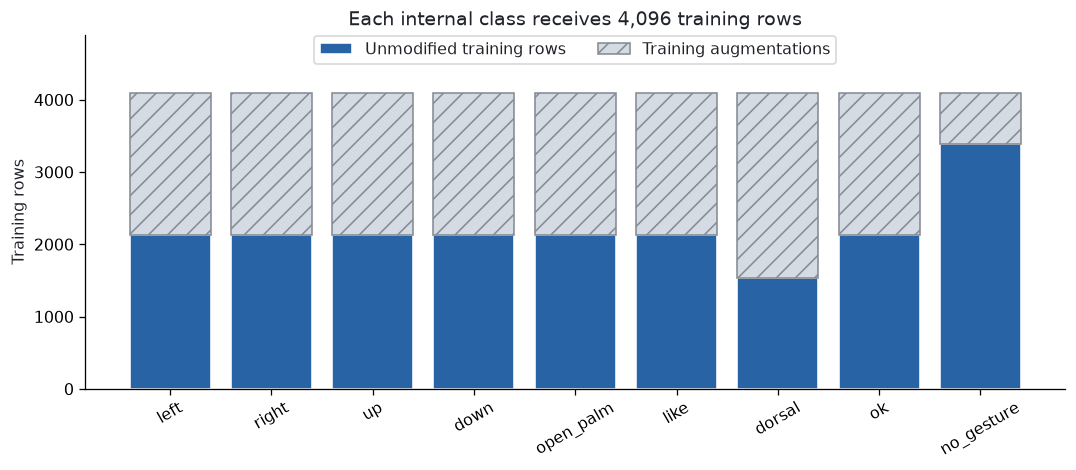

In [3]:
sources = json.loads((ROOT / 'data/v18_20/sources.json').read_text())
display(pd.DataFrame(sources).T[['url', 'license', 'subjects']])
balance = pd.read_csv(ARTIFACTS / 'dataset_balance.csv')
display(balance)
assert balance.balanced_train.nunique() == 1
assert balance.balanced_train.sum() == 36864
fig, ax = plt.subplots(figsize=(11, 4))
original = balance.balanced_train - balance.augmented
ax.bar(balance.gesture, original, color=BLUE, edgecolor='white', label='Unmodified training rows')
ax.bar(balance.gesture, balance.augmented, bottom=original, color='#d5dbe2', hatch='//', edgecolor=GRAY, label='Training augmentations')
ax.set(title='Each internal class receives 4,096 training rows', ylabel='Training rows')
ax.tick_params(axis='x', rotation=30); ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(.5, 1.02))
ax.set_ylim(0, 4900)
save_figure('class_balance')

### Split and leakage checks

Public participant overlap must be zero. Duplicate removal and source row counts
are recorded before fitting. The legacy overlap table is intentionally visible;
do not describe the old cache as an independent population test.

In [4]:
audit = json.loads((ARTIFACTS / 'data_audit.json').read_text())
display(pd.DataFrame([{'split': k, 'participants': v} for k, v in audit['subjects'].items()]))
assert all(v == 0 for v in audit['subject_overlap'].values())
print('Public subject overlap:', audit['subject_overlap'])
replay = load_npz(ROOT / 'models/gesture_online_replay_cache.npz')
replay_keys = set(feature_keys(replay['X']))
legacy_overlap = []
for split in ['validation', 'untouched_test']:
    data = load_npz(ROOT / f'models/gesture_online_{split}_cache.npz')
    legacy_overlap.append({'legacy_split': split, 'rows': len(data['X']),
                           'exact_or_rounded_replay_overlap': sum(k in replay_keys for k in feature_keys(data['X']))})
display(pd.DataFrame(legacy_overlap))
fingerprints = [{'file': str(p.relative_to(ROOT)), 'sha256': hashlib.sha256(p.read_bytes()).hexdigest()}
                for p in [ARTIFACTS / 'candidate.onnx', ARTIFACTS / 'balanced_train.npz',
                          ARTIFACTS / 'public_val.npz', ARTIFACTS / 'public_test.npz']]
display(pd.DataFrame(fingerprints))

,split,participants
0,train,5485
1,val,686
2,test,794


Public subject overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}


,legacy_split,rows,exact_or_rounded_replay_overlap
0,validation,2848,10
1,untouched_test,2915,6


,file,sha256
0,artifacts\v18_20\candidate.onnx,1aec12c072aa86e5f72de405ffba9f0914eb0a7939a19f...
1,artifacts\v18_20\balanced_train.npz,48e08b23f46702608dcb53e21c0dc03301d4bf5086616b...
2,artifacts\v18_20\public_val.npz,0b70a2392b038ab7ac1cb5edabdfa1f4197dac9ec9cc72...
3,artifacts\v18_20\public_test.npz,d5ca981d83c4801fc71b5e4ae9961966ed55019bc02c75...


### Optional data collection and retraining

Set the switches at the top to rebuild. Downloads are bounded by the collector's
per-source limits. Training takes only training rows and chooses the best epoch
using validation. Running these cells creates a **candidate**; it does not restart
the dashboard or replace the deployed model. If you change data or parameters
after inspecting test results, obtain a fresh held-out test cohort before claiming
a new independent test score.

In [5]:
if REBUILD_DATA:
    from scripts.collect_v18_20_data import collect_hagrid, collect_dorsal, collect_hand_metadata
    destination = ROOT / 'data/v18_20'
    collect_hagrid(destination)
    collect_hand_metadata(destination)
    collect_dorsal(destination, ROOT / 'models/hand_landmarker.task')
    prepare_data(ROOT, per_class=4096, seed=1820)
else:
    print('Using the saved, balanced training set and frozen evaluation splits.')
if RETRAIN:
    candidate_model, scaler, training_history = train_candidate(ROOT, epochs=80, seed=1820)
else:
    print('Using saved candidate weights; no training or production model writes.')

Using the saved, balanced training set and frozen evaluation splits.
Using saved candidate weights; no training or production model writes.


### Learning curves

Loss is cross-entropy; validation macro-F1 includes the internal unknown class.
Model selection uses validation only. The saved model is the best epoch, not
necessarily the final training epoch.

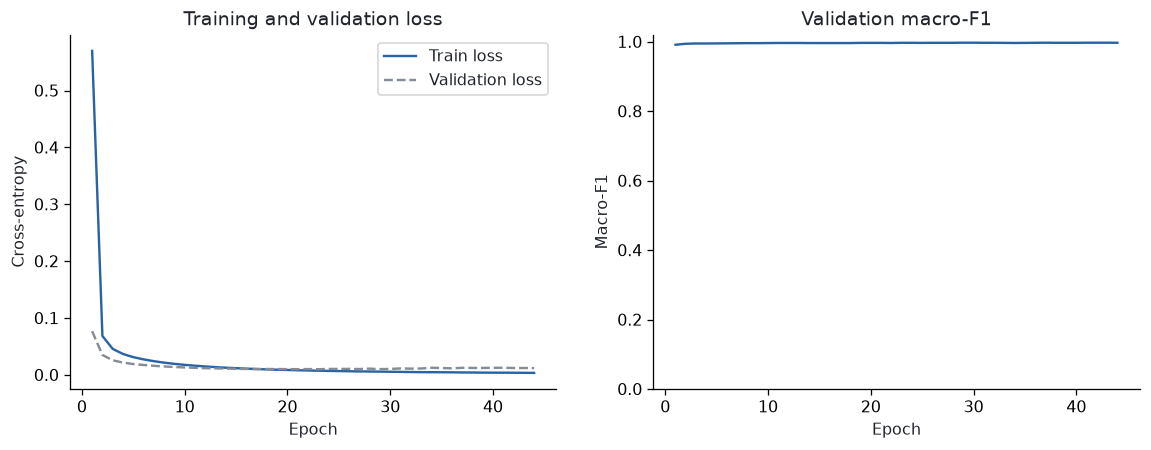

In [6]:
history = pd.read_csv(ARTIFACTS / 'training_history.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.epoch, history.train_loss, color=BLUE, label='Train loss')
axes[0].plot(history.epoch, history.val_log_loss, color=GRAY, linestyle='--', label='Validation loss')
axes[0].set(title='Training and validation loss', xlabel='Epoch', ylabel='Cross-entropy'); axes[0].legend()
axes[1].plot(history.epoch, history.val_macro_f1, color=BLUE)
axes[1].set(title='Validation macro-F1', xlabel='Epoch', ylabel='Macro-F1', ylim=(0, 1.02))
save_figure('learning_curves')

## Results

The next cells recompute predictions from the frozen ONNX candidate, including
the same geometry validation used by the dashboard. A static command acceptance
is not a temporal action firing. `no_gesture` includes rejected known poses as
well as true unknowns in the confusion matrix.

In [7]:
selection = json.loads((ARTIFACTS / 'selection.json').read_text())
config = RuntimeConfig(known_mass_floor=selection['known_mass_floor'],
                       confidence_floor=selection['confidence_floor'],
                       probability_margin_floor=selection['probability_margin_floor'])
test_data = load_npz(ARTIFACTS / 'public_test.npz')
probabilities, known_mass = predict_onnx(ARTIFACTS / 'candidate.onnx', test_data['X'])
result = evaluate(probabilities, known_mass, test_data, config)
baseline_probabilities, baseline_mass = predict_onnx(ARTIFACTS / 'baseline/gesture_mlp_production.onnx', test_data['X'])
baseline_result = evaluate(baseline_probabilities, baseline_mass, test_data, RuntimeConfig())
display(pd.DataFrame({'Baseline': baseline_result['metrics'], 'v18_20': result['metrics']}).round(4))
display(pd.DataFrame(result['report']).T.round(4))
saved_comparison = json.loads((ARTIFACTS / 'evaluation.json').read_text())
display(pd.DataFrame({k: v for k, v in saved_comparison.items() if k.startswith('legacy_test')}).round(4))

,Baseline,v18_20
raw_known_accuracy,0.9895,0.9978
raw_known_macro_f1,0.9897,0.9978
runtime_macro_f1,0.9439,0.9901
correct_command_rate,0.9291,0.9879
accepted_precision,0.9966,0.9990
unknown_false_accept_rate,0.0200,0.0040
known_rejection_rate,0.0709,0.0118


,precision,recall,f1-score,support
left,0.9975,0.9950,0.9962,400.000
right,0.9975,0.9975,0.9975,400.000
up,1.0000,0.9750,0.9873,400.000
down,1.0000,0.9800,0.9899,400.000
open_palm,1.0000,0.9875,0.9937,400.000
like,0.9974,0.9775,0.9874,400.000
dorsal,1.0000,1.0000,1.0000,331.000
ok,1.0000,0.9925,0.9962,400.000
no_gesture,0.9308,0.9960,0.9623,500.000
accuracy,0.9890,0.9890,0.9890,0.989


,legacy_test_baseline,legacy_test_v18_20
raw_known_accuracy,0.9915,0.9876
raw_known_macro_f1,0.9893,0.9836
runtime_macro_f1,0.9608,0.9549
correct_command_rate,0.9429,0.9401
accepted_precision,0.9882,0.9811
unknown_false_accept_rate,0.0140,0.0244
known_rejection_rate,0.0548,0.0577
known_mass_acceptance,0.9723,0.9604


### Runtime confusion matrices

Rows are true labels, columns are accepted predictions or rejection. Both views
include all 3,631 public-test observations: 3,131 command samples and 500 unknowns.

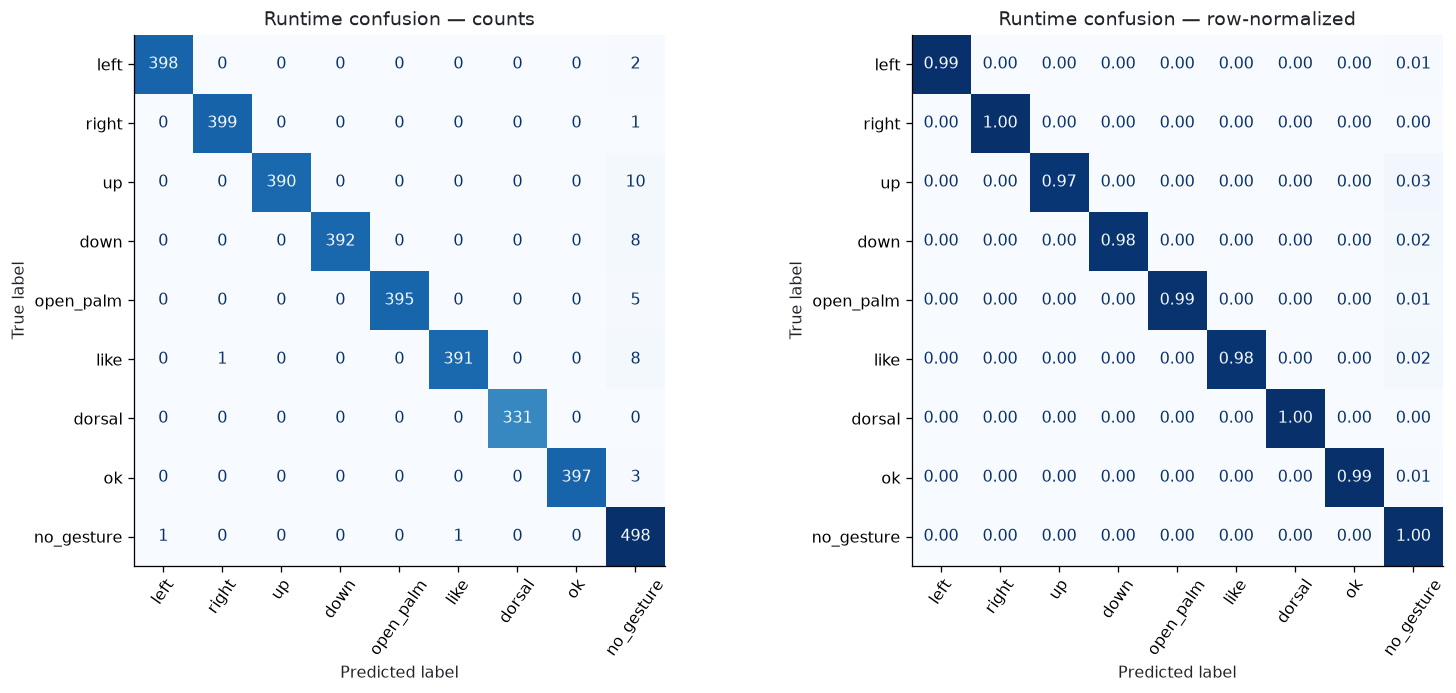

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
matrix = result['confusion']
for ax, normalize, title in zip(axes, [False, True], ['Runtime confusion — counts', 'Runtime confusion — row-normalized']):
    values = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1) if normalize else matrix
    ConfusionMatrixDisplay(values, display_labels=LABELS).plot(ax=ax, cmap='Blues', colorbar=False,
                                                              values_format='.2f' if normalize else 'd', xticks_rotation=55)
    ax.set_title(title)
save_figure('runtime_confusion')

### Classifier-only confusion and per-class runtime F1

Classifier-only results exclude unknowns and ignore runtime rejection. They are
reported separately to prevent a high raw score from hiding missed commands.

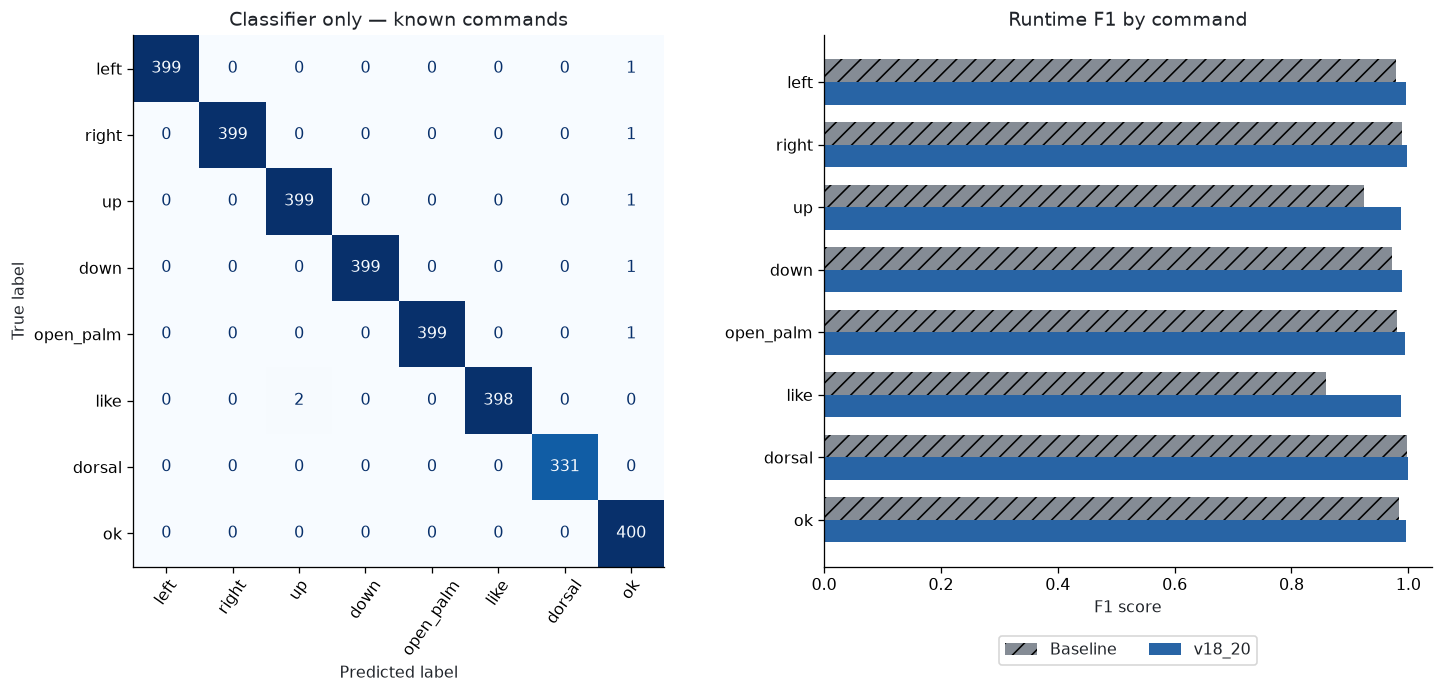

In [9]:
known = test_data['y'] < 8
raw_matrix = confusion_matrix(test_data['y'][known], probabilities[known].argmax(1), labels=np.arange(8))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay(raw_matrix, display_labels=LABELS[:8]).plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=55)
axes[0].set_title('Classifier only — known commands')
positions = np.arange(8)
axes[1].barh(positions - .18, [baseline_result['report'][x]['f1-score'] for x in LABELS[:8]], height=.36, color=GRAY, hatch='//', label='Baseline')
axes[1].barh(positions + .18, [result['report'][x]['f1-score'] for x in LABELS[:8]], height=.36, color=BLUE, label='v18_20')
axes[1].set(yticks=positions, yticklabels=LABELS[:8], xlim=(0, 1.04), xlabel='F1 score', title='Runtime F1 by command')
axes[1].legend(loc='lower center', bbox_to_anchor=(.5, -.20), ncol=2); axes[1].invert_yaxis()
save_figure('raw_confusion_and_class_f1')

### ROC and precision–recall curves

Each command is compared with all other commands **and unknowns**. Scores are
unconditional (`command probability × known mass`), not normalized known-class
probabilities that can appear confident on unknown hands.

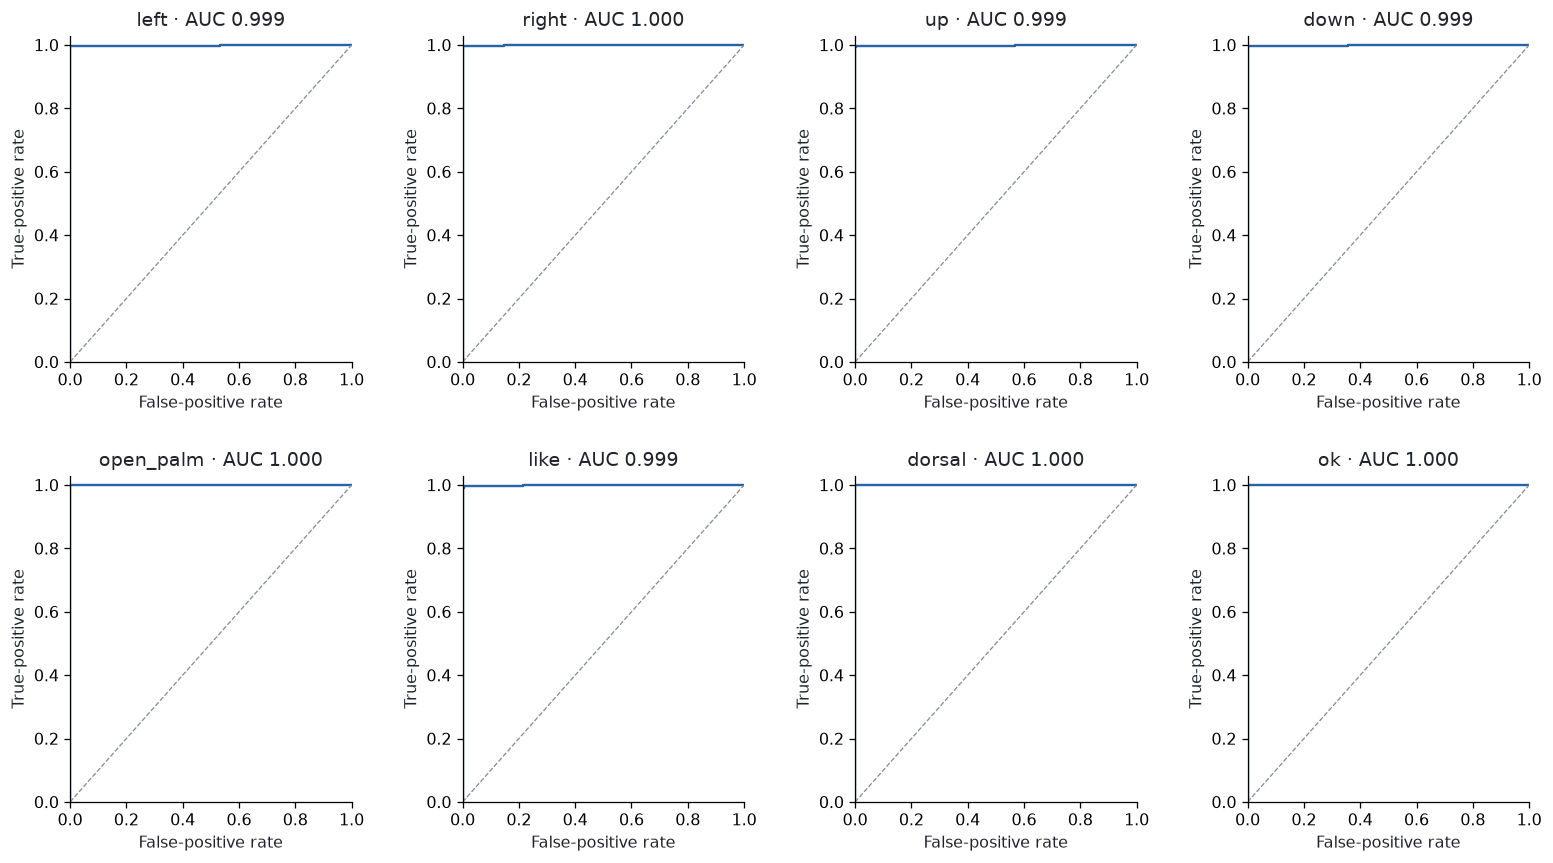

,gesture,ROC_AUC,average_precision
0,left,0.9987,0.9980
1,right,0.9996,0.9986
2,up,0.9986,0.9979
3,down,0.9991,0.9981
4,open_palm,1.0000,1.0000
5,like,0.9994,0.9977
6,dorsal,1.0000,1.0000
7,ok,1.0000,1.0000


In [10]:
unconditional = probabilities * known_mass[:, None]
curve_metrics = []
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for label, ax in enumerate(axes.flat):
    truth = test_data['y'] == label
    fpr, tpr, _ = roc_curve(truth, unconditional[:, label])
    auc = roc_auc_score(truth, unconditional[:, label])
    ap = average_precision_score(truth, unconditional[:, label])
    curve_metrics.append({'gesture': LABELS[label], 'ROC_AUC': auc, 'average_precision': ap})
    ax.plot(fpr, tpr, color=BLUE); ax.plot([0, 1], [0, 1], '--', color=GRAY, linewidth=.8)
    ax.set(title=f'{LABELS[label]} · AUC {auc:.3f}', xlabel='False-positive rate', ylabel='True-positive rate', xlim=(0, 1), ylim=(0, 1.03))
fig.tight_layout(pad=2.5)
save_figure('roc_curves')
display(pd.DataFrame(curve_metrics).round(4))

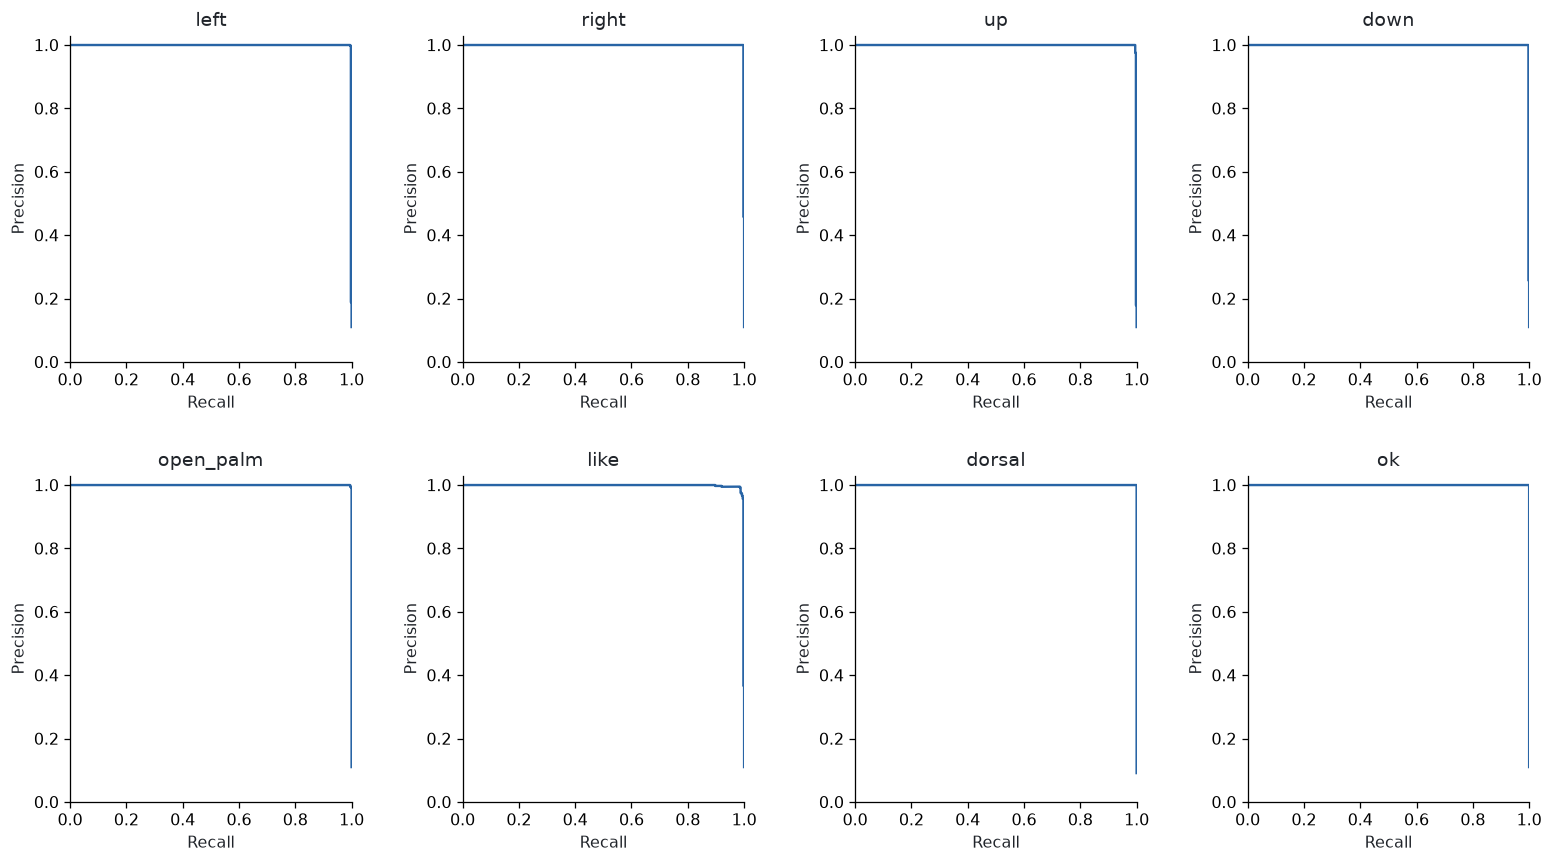

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for label, ax in enumerate(axes.flat):
    precision, recall, _ = precision_recall_curve(test_data['y'] == label, unconditional[:, label])
    ax.plot(recall, precision, color=BLUE)
    ax.set(title=LABELS[label], xlabel='Recall', ylabel='Precision', xlim=(0, 1), ylim=(0, 1.03))
fig.tight_layout(pad=2.5)
save_figure('precision_recall_curves')

### Confidence, rejection, and error review

The 0.95 line applies to known mass, not the displayed command confidence.
The table lists difficult public-test observations without changing their labels.

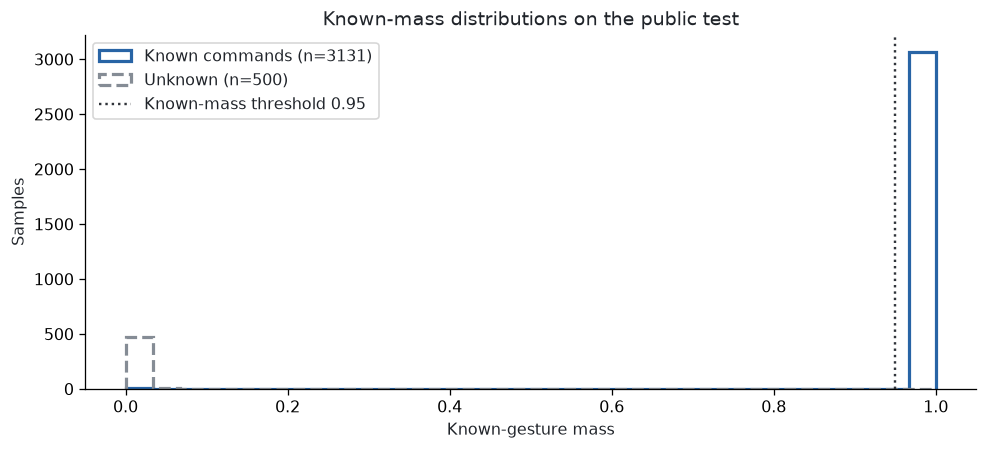

,row,true,prediction,known_mass,source
0,6,up,no_gesture,1.000,hagrid
1,7,down,no_gesture,1.000,hagrid
2,168,left,no_gesture,0.000,hagrid
3,169,right,no_gesture,0.000,hagrid
4,170,up,no_gesture,0.000,hagrid
5,171,down,no_gesture,0.000,hagrid
6,274,up,no_gesture,1.000,hagrid
7,275,down,no_gesture,1.000,hagrid
8,346,up,no_gesture,1.000,hagrid
9,347,down,no_gesture,1.000,hagrid


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(0, 1, 31)
ax.hist(known_mass[known], bins=bins, histtype='step', linewidth=2, color=BLUE, label=f'Known commands (n={known.sum()})')
ax.hist(known_mass[~known], bins=bins, histtype='step', linestyle='--', linewidth=2, color=GRAY, label=f'Unknown (n={(~known).sum()})')
ax.axvline(.95, color='#30343a', linestyle=':', label='Known-mass threshold 0.95')
ax.set(title='Known-mass distributions on the public test', xlabel='Known-gesture mass', ylabel='Samples'); ax.legend()
save_figure('known_mass_distribution')
errors = np.flatnonzero(result['predicted'] != test_data['y'])
display(pd.DataFrame([{'row': int(i), 'true': LABELS[test_data['y'][i]], 'prediction': LABELS[result['predicted'][i]],
                      'known_mass': round(float(known_mass[i]), 3), 'source': test_data['source'][i]}
                     for i in errors[:20]]))

### Dorsal subgroup coverage — limited to this test cohort

These groups use the original 11K Hands metadata, not image-based demographic
inferences. Small subgroup counts cannot establish fairness or universal accuracy.
All rows here are Dorsal, so the measure is recall with a Wilson 95% interval;
there is no all-class fairness claim. HaGRID demographic estimates were not used
for training or reported as demographic ground truth.

In [13]:
metadata = pd.read_csv(ROOT / 'data/v18_20/HandInfo.csv', dtype={'id': str}).set_index('imageName')
dorsal_indices = np.flatnonzero(test_data['source'] == 'dorsal')
subgroup_rows = []
for column in ['gender', 'skinColor']:
    values = np.array([str(metadata.loc[test_data['source_id'][i], column]) for i in dorsal_indices])
    for value in sorted(set(values)):
        chosen = dorsal_indices[values == value]; count = len(chosen)
        hits = int(np.sum(result['predicted'][chosen] == 6)); rate = hits / count
        z = 1.96; denominator = 1 + z*z/count
        center = (rate + z*z/(2*count))/denominator
        half = z*np.sqrt(rate*(1-rate)/count + z*z/(4*count*count))/denominator
        subgroup_rows.append({'dimension': column, 'group': value, 'test_images': count,
                              'participants': len(set(test_data['group'][chosen])), 'dorsal_recall': rate,
                              '95%_lower': center-half, '95%_upper': center+half})
display(pd.DataFrame(subgroup_rows).round(3))

,dimension,group,test_images,participants,dorsal_recall,95%_lower,95%_upper
0,gender,female,202,14,1.0,0.981,1.0
1,gender,male,129,7,1.0,0.971,1.0
2,skinColor,dark,44,3,1.0,0.920,1.0
3,skinColor,fair,116,7,1.0,0.968,1.0
4,skinColor,medium,171,11,1.0,0.978,1.0


### Latency and variable frame-rate checks

Classifier latency excludes MediaPipe, camera I/O, and notebook rendering.
The frame-rate table is a deterministic **temporal-gate simulation**, not measured
camera throughput. It checks that faster input never skips the required hold.

In [14]:
latency = benchmark(ARTIFACTS / 'candidate.onnx', test_data['X'])
display(pd.DataFrame([latency]))
from backend.runtime import TemporalGate
frame_rate_rows = []
for fps in [5, 8, 10, 15, 20, 30, 60]:
    gate = TemporalGate(config); first_action = None
    for frame in range(fps+1):
        decision = gate.update(np.eye(8)[6], now=frame/fps)
        if decision.execute:
            first_action = frame/fps; break
    assert first_action is not None and first_action >= config.minimum_hold_seconds
    frame_rate_rows.append({'simulated_input_fps': fps, 'first_action_seconds': round(first_action, 3)})
display(pd.DataFrame(frame_rate_rows))
live_report = ARTIFACTS / 'live_smoke_summary.json'
if live_report.exists():
    display(pd.DataFrame([json.loads(live_report.read_text())]))
else:
    print('No saved full-camera benchmark. Run the optional live test below.')
regression_path = ARTIFACTS / 'dorsal_live_regression.json'
if regression_path.exists():
    display(pd.DataFrame([json.loads(regression_path.read_text())]))

,p50_ms,p95_ms,p99_ms,note
0,0.0282,0.041405,0.050801,ONNX classifier only; full camera pipeline is ...


,simulated_input_fps,first_action_seconds
0,5,0.400
1,8,0.250
2,10,0.200
3,15,0.200
4,20,0.200
5,30,0.200
6,60,0.183


,frames,labelled_accuracy,pipeline_p50_ms,pipeline_p95_ms,pipeline_p99_ms,over_100ms,no_hand_frames,inference_fps,model,source
0,150,Not measured: no ground-truth labels supplied,16.78875,18.64647,27.339108,1,0,9.926709,v18_20,Live NCM camera via local inference engine


,case,frames,before_accepted_actions,after_accepted_actions,first_action_seconds,evidence,raw_classifier_known_mass
0,User-held Dorsal; captured target NCM camera f...,80,0,76,0.4,"Replay of development case, not fresh live gen...",Preserved; geometry supplied independent support


### Live camera test — NCM, local webcam, or Colab

Set `RUN_LIVE_CAMERA = True` and select the source at the top, then run this cell.
For NCM, start the project backend and connect the board. For local webcam, allow
camera access. For Colab, choose `colab`; the browser asks for camera permission
and shows a Stop button. Each test is bounded by `LIVE_SECONDS` and releases its
local camera afterward. It uses the **deployed model in `models/`**, whose hash is
shown below. The production dashboard remains capped at 10 FPS even if camera
capture rises above 10 FPS.

Set `EXPECTED_GESTURE` only when deliberately holding that pose for the complete
test. Test each of the eight poses, transitions, and `no_gesture` with several
people, lighting conditions, distances, and both hands. Without a supplied truth
label, this measures timing and detection availability, not accuracy.

In [15]:
from research.live_camera import live_camera
print('Deployed model SHA256:', hashlib.sha256((ROOT / 'models/gesture_mlp_production.onnx').read_bytes()).hexdigest())
if RUN_LIVE_CAMERA:
    live_results = live_camera(ROOT, source=LIVE_SOURCE, duration=LIVE_SECONDS, expected_label=EXPECTED_GESTURE)
    if len(live_results):
        elapsed = live_results.elapsed_s.iloc[-1] - live_results.elapsed_s.iloc[0]
        summary = {'frames': len(live_results), 'observed_inference_fps': (len(live_results)-1)/max(elapsed, .001),
                   'pipeline_p50_ms': live_results.total_ms.median(), 'pipeline_p95_ms': live_results.total_ms.quantile(.95),
                   'frames_over_100ms': int((live_results.total_ms > 100).sum()),
                   'no_hand_frames': int((live_results.status == 'no_hand').sum())}
        if EXPECTED_GESTURE is not None:
            summary['labelled_frame_accuracy'] = float((live_results.prediction == EXPECTED_GESTURE).mean())
        display(pd.DataFrame([summary])); display(live_results.tail(10))
        live_results.to_csv(ARTIFACTS / 'last_live_test.csv', index=False)
else:
    print('Camera is off. Enable RUN_LIVE_CAMERA to perform an interactive, labelled live test.')

Deployed model SHA256: 1aec12c072aa86e5f72de405ffba9f0914eb0a7939a19fcb069152b46931fc95
Camera is off. Enable RUN_LIVE_CAMERA to perform an interactive, labelled live test.


## Takeaways

The balanced public-data model improves the new public-test command acceptance
and unknown rejection substantially. It recognizes all 331 Dorsal public-test
examples, but that does not prove the exact live camera pose in the screenshot
is solved for every person. Legacy test performance is slightly lower on some
cases; retain the baseline for comparison and collect reviewed live failures.

The notebook separates raw classification, runtime rejection, timing, participant
coverage, and live labelled tests so none can be mistaken for another. The next
evidence needed is repeated target-camera testing with new people and real
lighting/occlusion variation. Add those recordings with participant IDs, split
people before augmentation, and keep a fresh evaluation cohort.

Reproduction scripts: `scripts/collect_v18_20_data.py`, `research/v18_20.py`,
`scripts/qualify_v18_20.py`. Qualification and model replacement are separate from
this notebook's normal read-only metrics run. The previous model remains under
`artifacts/v18_20/baseline/`.